# 연구를 위한 Deep Agent 설계(Deep Agent for Research)

이전까지 알아본 모든 내용을 종합하여 Deep Agent를 완성합니다.

**Context Offloading**, **Sub-agent Delegation**, **Strategic Thinking** 을 결합하여 복잡한 리서치 워크플로우를 최적화하는 방법을 다룹니다.

**🏆 핵심 내용**

*   **Deep Agent 아키텍처**: 파일 기반 컨텍스트 관리 및 토큰 효율화
*   **Search Tool**: Tavily API 연동, 웹페이지 요약, 파일 저장
*   **Think Tool**: 리서치 진행 상황 분석 및 전략적 의사결정 도구
*   **Sub-agent**: Research Sub-agent 구성 및 작업 위임

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("Deep-Agent-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
Deep-Agent-Tutorial


## Deep Agent 아키텍처 및 도구 설계

![agent_header](./assets/agent_header.png)

**핵심 구조**

*   **TODO List**: 작업 진행 상황 관리
*   **File System**: 원본 데이터 저장 (Context Offloading)
*   **Sub-agent**: 리서치 작업 위임 및 컨텍스트 분리

## 도구(Research)

이 모듈은 리서치 에이전트를 위한 검색 및 콘텐츠 처리 유틸리티 제공.
웹 검색 기능 및 콘텐츠 요약 도구 포함.

### Search Tool 설계

웹 검색 결과를 파일로 저장하고 요약본만 에이전트에게 전달하여 토큰 효율성을 극대화합니다.

*   **`run_tavily_search`**: Tavily API 기반 웹 검색
*   **`summarize_webpage_content`**: gpt 활용 구조적 요약 및 파일명 생성
*   **`process_search_results`**: HTML → Markdown 변환 및 결과 처리
*   **`tavily_search` (Tool)**: 검색-요약-저장 통합 프로세스, 최소 정보 반환
*   **`think_tool`**: 리서치 결과 분석 및 전략적 의사결정 지원

In [2]:
from typing import Literal
from tavily import TavilyClient


tavily_client = TavilyClient()


def run_web_search(
    search_query: str,
    max_results: int = 2,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = True,
) -> dict:
    """Perform search using Tavily API for a single query.

    Args:
        search_query: Search query to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        Search results dictionary
    """
    result = tavily_client.search(
        search_query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )
    return result

In [3]:
result = run_web_search("테디노트 rag 에 대해서 검색해줘")
print(result)

{'query': '테디노트 rag 에 대해서 검색해줘', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.youtube.com/watch?v=1scMJH93v0M', 'title': 'langchain 의 #RAG 파이프라인 이해해보기 - 네이버 뉴스기사 기반 ...', 'content': '테디노트 TeddyNote•16K views · 45:21. Go to channel 테디노트 TeddyNote ... 긴 문서(long context) 에 대한 참신한 RAG 방법론: RAPTOR!', 'score': 0.9999497, 'raw_content': None}, {'url': 'https://www.youtube.com/channel/UCt2wAAXgm87ACiQnDHQEW6Q', 'title': '테디노트 TeddyNote - YouTube', 'content': '테디노트 TeddyNote · EP01. Easily understand the operation process of #RAG! · Videos · LangChain 튜토리얼 · 깃헙(Github) 블로그 만들기 - 시즌2 · 깃헙(Github) 블로그', 'score': 0.99968493, 'raw_content': None}], 'response_time': 4.76, 'request_id': 'e994ab49-c4c8-4325-b5f7-9f76ff8d98d5'}


In [4]:
result["results"][0]

{'url': 'https://www.youtube.com/watch?v=1scMJH93v0M',
 'title': 'langchain 의 #RAG 파이프라인 이해해보기 - 네이버 뉴스기사 기반 ...',
 'content': '테디노트 TeddyNote•16K views · 45:21. Go to channel 테디노트 TeddyNote ... 긴 문서(long context) 에 대한 참신한 RAG 방법론: RAPTOR!',
 'score': 0.9999497,
 'raw_content': None}

In [5]:
from datetime import datetime


def get_current_time() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%b %-d, %Y %H:%M:%S (%A)")

In [6]:
get_current_time()

'May 19, 2026 09:30:16 (Tuesday)'

## 웹 검색 결과 컨텍스트 최적화를 위한 요약 파이프라인

요약된 결과 형식
- `filename`: 요약된 파일명
- `summary`: 요약된 내용

연구 방향을 잡기 위한 최소한의 요약을 작성합니다. 목표는 수집한 정보의 세부를 모두 남기는 것이 아니라, 에이전트가 어떤 정보를 모았는지 알 수 있게 하는 것입니다.
<webpage_content>
{webpage_content}
</webpage_content>
다음에 맞춰 **매우 간결한** 요약을 작성하세요:
1. 주제/대상: 1–2문장
2. 정보 유형(사실, 튜토리얼, 뉴스, 분석 등)
3. 가장 중요한 발견·요점 1–2개
4. 요약 본문은 **한국어**로 작성
전체 요약은 **150단어 이내**로 유지하세요. 에이전트가 이 파일 내용을 보고 추가 검색이 필요한지, 이 출처를 쓸지 판단할 수 있어야 합니다.
내용 유형과 주제가 드러나는 설명적 파일명을 만드세요 (예: `mcp_protocol_overview.md`, `ai_safety_research_2024.md`).
출력 형식:
```json
{{
   "filename": "descriptive_filename.md",
   "summary": "주제와 핵심 발견에 집중한, 150단어 이내의 매우 짧은 요약"
}}

오늘 날짜: {date}

In [7]:
# 요약 프롬프트
SUMMARIZE_WEB_SEARCH = """You are creating a minimal summary for research steering - your goal is to help an agent know what information it has collected, NOT to preserve all details.

<webpage_content>
{webpage_content}
</webpage_content>

Create a VERY CONCISE summary focusing on:
1. Main topic/subject in 1-2 sentences
2. Key information type (facts, tutorial, news, analysis, etc.)
3. Most significant 1-2 findings or points
4. Write the summary in Korean

Keep the summary under 150 words total. The agent needs to know what's in this file to decide if it should search for more information or use this source.

Generate a descriptive filename that indicates the content type and topic (e.g., "mcp_protocol_overview.md", "ai_safety_research_2024.md").

Output format:
```json
{{
   "filename": "descriptive_filename.md",
   "summary": "Very brief summary under 150 words focusing on main topic and key findings"
}}
```

Today's date: {date}
"""

In [ ]:
from langchain_core.messages import HumanMessage, ToolMessage
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

from util.chat_model_enums import LangChainChatModel

# 요약을 위한 LLM 초기화
summarization_model = init_chat_model(
    model=LangChainChatModel.OPENAI_GPT_4O_MINI, temperature=0.0
)


# structured output
class Summary(BaseModel):
    """Schema for webpage content summarization."""

    filename: str = Field(description="Name of the file to store.")
    summary: str = Field(description="Key learnings from the webpage.")


# tavily search -> List[raw_content] -> List[Summary]
def summarize_webpage_contents(webpage_contents: list[str]) -> list[Summary]:
    """Summarize multiple webpage contents in parallel using batch processing.

    LangChain의 batch() 메서드를 활용하여 여러 웹페이지 콘텐츠를 병렬로 요약

    Args:
        webpage_contents: List of raw webpage contents to summarize

    Returns:
        List of Summary objects with filename and summary for each content
    """
    if not webpage_contents:
        return []

    # 구조화된 출력 모델 설정
    structured_model = summarization_model.with_structured_output(Summary)

    # 각 콘텐츠에 대한 메시지 리스트 생성 (batch 입력 형식)
    batch_inputs = [
        [
            HumanMessage(
                content=SUMMARIZE_WEB_SEARCH.format(
                    webpage_content=content, date=get_current_time()
                )
            )
        ]
        for content in webpage_contents
    ]

    try:
        # batch() 메서드로 병렬 처리 실행
        summaries = structured_model.batch(batch_inputs)
        return summaries

    except Exception as e:
        # 실패시 원문 검색(앞 1000자) 리스트 반환
        print(f"Batch processing failed: {e}, falling back to sequential processing")
        return [
            Summary(
                filename=f"search_result_{i}.md",
                summary=(content[:1000] + "..." if len(content) > 1000 else content),
            )
            for i, content in enumerate(webpage_contents)
        ]

In [9]:
# 요약 테스트 결과(2건)
summarize_webpage_contents(result["results"])

[Summary(filename='rag_pipeline_understanding_naver_news.md', summary='이 영상은 긴 문서에 대한 RAG(정보 검색 및 생성) 방법론인 RAPTOR에 대해 설명합니다. 주요 정보 유형은 튜토리얼이며, 긴 문서 처리에 대한 혁신적인 접근 방식을 제시합니다.'),
 Summary(filename='teddy_note_youtube_channel_summary.md', summary='테디노트(TeddyNote) 유튜브 채널은 RAG 운영 프로세스와 LangChain 튜토리얼을 쉽게 이해할 수 있도록 돕는 콘텐츠를 제공합니다. 주요 정보 유형은 튜토리얼이며, 특히 깃헙 블로그 만들기와 관련된 시즌2 콘텐츠가 포함되어 있습니다.')]

In [10]:
def process_search_results(results: dict) -> list[dict]:
    """Process search results by summarizing content in parallel using batch processing.

    LangChain의 batch() 메서드를 활용하여 여러 검색 결과를 병렬로 요약합니다.
    순차 처리 대비 처리 시간을 대폭 단축할 수 있습니다.

    Args:
        results: Tavily search results dictionary

    Returns:
        List of processed results with summaries
    """
    search_results = results.get("results", [])

    if not search_results:
        return []

    # 모든 raw_content를 리스트로 추출 (batch 입력용)
    raw_contents = [result.get("raw_content", "") for result in search_results]

    # batch 방식으로 모든 콘텐츠를 병렬 요약 처리 (summarize_webpage_contents 함수 활용)
    summary_objects = summarize_webpage_contents(raw_contents)

    # 요약 결과와 원본 검색 결과를 결합하여 최종 결과 생성
    processed_results = []
    for result, summary_obj in zip(search_results, summary_objects):
        processed_results.append(
            {
                "url": result["url"],
                "title": result["title"],
                "summary": summary_obj.summary,
                "filename": summary_obj.filename,
                "raw_content": result.get("raw_content", ""),
            }
        )

    return processed_results

In [11]:
process_search_results(result)

[{'url': 'https://www.youtube.com/watch?v=1scMJH93v0M',
  'title': 'langchain 의 #RAG 파이프라인 이해해보기 - 네이버 뉴스기사 기반 ...',
  'summary': '이 웹페이지는 특정 주제에 대한 정보가 없습니다. 정보 유형은 비어 있으며, 주요 발견이나 포인트도 없습니다. 추가 정보를 검색할 필요가 있습니다.',
  'filename': 'webpage_summary_template.md',
  'raw_content': None},
 {'url': 'https://www.youtube.com/channel/UCt2wAAXgm87ACiQnDHQEW6Q',
  'title': '테디노트 TeddyNote - YouTube',
  'summary': '이 문서는 특정 주제에 대한 정보가 포함되어 있지 않습니다. 주요 정보 유형은 없음이며, 따라서 중요한 발견이나 포인트도 없습니다. 추가 정보를 검색할 필요가 있습니다.',
  'filename': 'webpage_summary_template.md',
  'raw_content': None}]

In [12]:
from langchain_core.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from typing_extensions import Annotated, Literal
from deep_agents_from_scratch.state import DeepAgentState


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[
        Literal["general", "news", "finance"], InjectedToolArg
    ] = "general",
) -> Command:
    """웹 검색을 수행하고 상세한 결과를 파일에 저장하면서 최소한의 컨텍스트만 반환합니다.

    웹 검색을 수행하고 전체 콘텐츠를 파일에 저장하여 컨텍스트 오프로딩을 수행합니다.
    에이전트가 다음 단계를 결정하는 데 도움이 되는 필수 정보만 반환합니다.

    Args:
        query: 실행할 검색 쿼리
        state: 파일 저장을 위한 주입된 에이전트 상태
        tool_call_id: 주입된 도구 호출 식별자
        max_results: 반환할 최대 결과 수 (기본값: 1)
        topic: 토픽 필터 - 'general', 'news', 또는 'finance' (기본값: 'general')

    Returns:
        전체 결과를 파일에 저장하고 최소한의 요약을 제공하는 Command
    """
    # 검색 실행
    search_results = run_web_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # 결과 처리 및 요약
    processed_results = process_search_results(search_results)

    # 각 결과를 파일에 저장하고 요약 준비
    files = state.get("files", {})
    saved_files = []
    summaries = []

    for i, result in enumerate(processed_results):
        # 요약에서 AI가 생성한 파일명 사용
        filename = result["filename"]

        # 전체 상세 정보를 포함한 파일 콘텐츠 생성
        file_content = f"""
            # Search Result: {result['title']}

            **URL:** {result['url']}
            **Query:** {query}
            **Date:** {get_current_time()}

            ## Summary
            {result['summary']}

            ## Raw Content
            {result['raw_content'] if result['raw_content'] else 'No raw content available'}
        """

        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"- {filename}: {result['summary']}...")


    # 도구 메시지를 위한 최소한의 요약 생성 - 수집된 내용에 집중
    # chr(10) = \n
    summary_text = f"""
        🔍 Found {len(processed_results)} result(s) for '{query}':

        {chr(10).join(summaries)}

        Files: {', '.join(saved_files)}
        💡 Use read_file() to access full details when needed.
    """

    return Command(
        update={
            "files": files,
            "messages": [ToolMessage(summary_text, tool_call_id=tool_call_id)],
        }
    )

### 🔍 연구 진행과 의사결정을 위한 전략적 성찰 도구

검색을 할 때마다 이 도구를 사용해 결과를 분석하고 다음 단계를 체계적으로 계획하세요. 연구 워크플로에 의도적인 멈춤(Pause)을 넣어, 질 높은 판단을 내리도록 합니다.

#### 📍 사용 시점

* **검색 결과를 받은 뒤:** 어떤 핵심 정보를 찾았는가?
* **다음 단계를 정하기 전:** 포괄적으로 답하기에 충분한가?
* **연구 공백을 점검할 때:** 아직 어떤 구체적 정보가 부족한가?
* **연구를 마무리하기 전:** 지금 완전한 답을 줄 수 있는가?
* **질문의 복잡도 한계:** 검색 횟수 한도에 도달했는가?

#### 📝 성찰에 포함할 내용

1. **현재까지의 발견 분석** — 어떤 구체적 정보를 모았는가?
2. **공백 평가** — 여전히 빠진 핵심 정보는 무엇인가?
3. **품질 평가** — 좋은 답을 위해 근거와 예시가 충분한가?
4. **전략적 결정** — 검색을 이어갈 것인가, 답을 제시할 것인가?

---

#### ⚙️ 파라미터 (Args)

* **`reflection`**: 연구 진행, 발견, 공백, 다음 단계에 대한 상세한 성찰 내용

#### ↩️ 반환값 (Returns)

* 의사결정을 위해 성찰이 기록되었음을 확인하는 메시지

In [14]:
@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

## Deep Agent 구성

리서치 에이전트의 전체 구조를 조립합니다.

*   **Research Sub-agent**: `tavily_search`, `think_tool` 할당 → 정보 탐색 및 분석 집중
*   **Parent Agent**: `task`(위임), `think_tool`, 파일 시스템 도구 할당 → 전체 조율 및 관리
*   **효과**: 명확한 역할 분리를 통한 복잡한 워크플로우의 체계적 관리

In [15]:
from datetime import datetime

from IPython.display import display
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from utils import show_prompt, stream_agent

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.prompts import (
    FILE_USAGE_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_USAGE_INSTRUCTIONS,
    TODO_USAGE_INSTRUCTIONS,
)

from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool
from deep_agents_from_scratch.todo_tools import write_todos, read_todos

# LLM 객체 초기화
model = init_chat_model(model=LangChainChatModel.OPENAI_GPT_4O_MINI, temperature=0.0)

# 리서치 서브에이전트 동시 실행 최대 개수 및 반복 횟수 제한 설정
max_concurrent_research_units = 3
max_researcher_iterations = 3

# 리서치 서브에이전트에 할당할 도구 리스트 (웹 검색 및 전략적 사고 도구)
sub_agent_tools = [tavily_search, think_tool]
# 메인 에이전트에 할당할 파일 시스템 및 TODO 관리 도구, 전략적 사고 도구 포함
built_in_tools = [ls, read_file, write_file, write_todos, read_todos, think_tool]

# 리서치 서브에이전트 구성 정보 (이름, 설명, 프롬프트, 도구 목록)
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": RESEARCHER_INSTRUCTIONS.format(date=get_current_time()),
    "tools": ["tavily_search", "think_tool"],
}

# 서브에이전트에게 작업 위임을 위한 Task Tool 생성 (모델, 상태, 도구 전달)
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

# 메인 에이전트에 위임 도구 포함 전체 도구 리스트 생성 (검색 도구 직접 사용 가능)
delegation_tools = [task_tool] # sub agent
all_tools = (
    sub_agent_tools + built_in_tools + delegation_tools
)  # search available to main agent for trivial cases

# 서브에이전트 프롬프트 생성 (최대 동시 리서치 개수, 반복 횟수, 날짜 포함)
SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%a %b %-d, %Y"),
)

---

당신은 사용자가 입력한 주제에 대해 연구를 수행하는 연구 어시스턴트(Research Assistant)입니다. 참고로 오늘 날짜는 {date}입니다.

<작업>
당신의 임무는 도구를 사용하여 사용자의 입력 주제에 대한 정보를 수집하는 것입니다.
제공된 어떤 도구든 활용하여 연구 질문에 답하는 데 도움이 되는 자료를 찾을 수 있습니다.
이 도구들은 직렬(series) 또는 병렬(parallel)로 호출할 수 있으며, 연구는 도구 호출 루프(tool-calling loop) 내에서 진행됩니다.
</작업>

<사용 가능한 도구>
당신은 두 가지 주요 도구에 접근할 수 있습니다:

1. **`tavily_search`**: 정보 수집을 위한 웹 검색 수행용
2. **`think_tool`**: 연구 과정 중의 성찰(reflection) 및 전략적 계획 수립용

**초중요(CRITICAL): 매 검색이 끝난 후에는 반드시 `think_tool`을 사용하여 결과를 성찰하고 다음 단계를 계획해야 합니다.**
</사용 가능한 도구>

<지시사항>
시간이 제한된 인간 연구자처럼 생각하고, 다음 단계를 따르세요:

1. **질문을 주의 깊게 읽기** - 사용자가 필요로 하는 구체적인 정보는 무엇인가?
2. **광범위한 검색으로 시작하기** - 처음에는 넓고 포괄적인 검색어(query)를 사용하세요.
3. **매 검색 후 멈춰서 평가하기** - 답변하기에 충분한 정보를 얻었는가? 아직 부족한 부분은 무엇인가?
4. **정보가 수집됨에 따라 좁고 구체적인 검색 실행하기** - 정보의 공백(gaps)을 채우세요.
5. **자신 있게 답변할 수 있을 때 멈추기** - 완벽함을 추구하며 끊임없이 검색하지 마세요.
</지시사항>

<엄격한 제한 사항>
**도구 호출 예산 (과도한 검색 방지):**

* **단순한 질문**: 최대 1~2회 검색 도구 호출
* **일반적인 질문**: 최대 2~3회 검색 도구 호출
* **매우 복잡한 질문**: 최대 5회 검색 도구 호출
* **절대 중단 규칙**: 올바른 출처를 찾지 못하더라도 검색 도구 호출이 5회에 도달하면 무조건 멈추세요.

**다음의 경우 즉시 중단할 것:**

* 사용자의 질문에 포괄적으로 답변할 수 있을 때
* 질문과 관련된 유의미한 예시/출처를 3개 이상 확보했을 때
* 최근 2번의 검색에서 비슷한 정보가 중복해서 반환되었을 때
</엄격한 제한 사항>

<사고 과정 표시>
매 검색 도구를 호출한 후에는, `think_tool`을 사용하여 다음 기준에 따라 결과를 분석하세요:

* 어떤 핵심 정보를 찾았는가?
* 부족한 부분은 무엇인가?
* 질문에 포괄적으로 답변할 만큼 충분한 정보를 확보했는가?
* 검색을 더 진행해야 하는가, 아니면 이제 답변을 제시해야 하는가?
</사고 과정 표시>

In [16]:
# 리서처 에이전트 프롬프트 출력
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 1-2 search tool calls maximum                                                        │
│  - **Normal queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Very Complex queries**: Use up to 5 search tool calls maximum                                              │
│  - **Always stop**: After 5 search tool calls if you c

---

#### TODO 관리 (TODO MANAGEMENT)

사용자의 요청에 따라 다음을 수행하세요:

1. 사용자의 요청이 들어오면 가장 먼저 도구 설명서에 따라 `write_todos` 도구를 사용하여 TODO를 생성할 것.
2. TODO 항목 하나를 완수할 때마다, 전체 계획을 상기(remind)하기 위해 `read_todos` 도구를 사용하여 TODO 목록을 다시 읽을 것.
3. 수행한 작업과 TODO 내용에 대해 스스로 성찰(Reflect)할 것.
4. 해당 작업을 '완료(completed)'로 표시하고, 다음 TODO 항목으로 넘어갈 것.
5. 모든 TODO가 완료될 때까지 이 과정을 계속 반복할 것.

**중요:** **어떤(ANY)** 사용자 요청이든 예외 없이 항상 위의 가이드라인에 따라 TODO 형태의 리서치 계획을 세우고 리서치를 진행하세요.
**중요:** 추적하고 관리해야 할 TODO 항목의 수를 최소화하기 위해, 여러 리서치 작업들을 묶어서(batch) **단일 TODO**로 처리하는 것을 목표로 하세요.

================================================================================

#### 파일 시스템 사용 (FILE SYSTEM USAGE)

컨텍스트를 유지하고 저장할 수 있도록 가상 파일 시스템(virtual file system)에 접근할 수 있습니다.

##### 워크플로 프로세스

1. **상황 파악 (Orient)**: 작업을 시작하기 전에 `ls()`를 사용하여 기존 파일들을 확인하세요.
2. **저장 (Save)**: 나중에 참고할 수 있도록 `write_file()`을 사용하여 사용자의 요청 사항을 파일로 저장하세요.
3. **리서치 (Research)**: 리서치를 진행하세요. 검색 도구가 파일들을 작성할 것입니다.
4. **읽기 (Read)**: 수집된 출처 자료가 충분하다고 판단되면, 파일들을 읽고 이를 활용하여 사용자의 질문에 직접 답변하세요.

================================================================================

#### 서브 에이전트 위임 (SUB-AGENT DELEGATION)

특정 작업을 서브 에이전트(하위 에이전트)에게 위임할 수 있습니다.

<작업>
당신의 역할은 특정 리서치 작업을 서브 에이전트들에게 위임하여 전체 리서치를 조율(coordinate)하는 것입니다.
</작업>

<사용 가능한 도구>

1. **`task(description, subagent_type)`**: 특화된 서브 에이전트에게 리서치 작업을 위임합니다.
* `description`: 명확하고 구체적인 리서치 질문 또는 작업 내용
* `subagent_type`: 사용할 에이전트의 유형 (예: "research-agent")


2. **`think_tool(reflection)`**: 위임된 각 작업의 결과를 성찰하고 다음 단계를 계획합니다.
* `reflection`: 작업 결과 및 다음 단계에 대한 상세한 성찰 내용



**병렬 리서치 (PARALLEL RESEARCH)**: 서로 독립적인 여러 개의 리서치 방향을 식별한 경우, 단일 응답 내에서 **`task`** 도구를 여러 번 호출하여 병렬 실행(parallel execution)을 활성화하세요. 한 번의 이터레이션(반복) 당 최대 3개의 에이전트를 병렬로 사용하세요.
</사용 가능한 도구>

<엄격한 제한 사항>
**작업 위임 예산 (과도한 위임 방지):**

* **집중적인 리서치 지향** - 단순한 질문에는 단일 에이전트를 사용하고, 다수의 에이전트는 명확한 이점이 있거나 사용자의 요청에 따라 독립적인 리서치 방향이 여러 개일 때만 사용하세요.
* **충분할 때 중단** - 과도하게 리서치하지 마세요. 충분한 정보를 얻었다면 중단하세요.
* **이터레이션 제한** - 적절한 출처를 찾지 못했더라도 작업 위임이 3회에 도달하면 멈추세요.
</엄격한 제한 사항>

<확장 규칙 (Scaling Rules)>
**단순한 사실 확인, 목록 작성 및 순위 지정**은 1개의 서브 에이전트를 사용할 수 있습니다:

* *예시*: "샌프란시스코의 상위 10개 커피숍 목록 작성" → 1개의 서브 에이전트 사용, `findings_coffee_shops.md`에 저장

**비교 분석**은 비교할 각 요소마다 별도의 서브 에이전트를 사용할 수 있습니다:

* *예시*: "AI 안전성에 대한 OpenAI vs. Anthropic vs. DeepMind의 접근 방식 비교" → 3개의 서브 에이전트 사용
* 조사 결과를 별도의 파일로 저장: `findings_openai_safety.md`, `findings_anthropic_safety.md`, `findings_deepmind_safety.md`

**다면적 리서치**는 각기 다른 측면에 대해 병렬 에이전트를 사용할 수 있습니다:

* *예시*: "재생 에너지 리서치: 비용, 환경적 영향, 채택률" → 3개의 서브 에이전트 사용
* 조사 결과를 각 측면별로 별도의 파일에 정리

**중요 알림 (Important Reminders):**

* 각 **`task`** 호출은 기존과 격리된 컨텍스트(isolated context)를 가진 전용 리서치 에이전트를 새롭게 생성합니다.
* 서브 에이전트들은 서로의 작업 내용을 볼 수 없습니다. 따라서 혼자서도 수행 가능한 완전하고 독립적인 지시사항을 제공해야 합니다.
* 명확하고 구체적인 언어를 사용하세요. 작업 설명(`description`)에 약어나 줄임말을 피하세요.
</확장 규칙>

In [17]:
# TODO 관리, 파일 시스템 사용, 서브에이전트 위임 관련 프롬프트를 하나의 문자열로 통합
INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)

# 통합된 프롬프트를 화면에 출력하여 에이전트의 역할 및 사용법 안내
show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # TODO MANAGEMENT                                                                                              │
│  Based upon the user's request:                                                                                 │
│  1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.           │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan.  │
│  3. Reflect on what you've done and the TODO.                                                                   │
│  4. Mark you task as completed, and proceed to the next TODO.                                                   │
│  5. Continue this process until you have completed all TODOs.                                                   │
│                                                                                                                 │
│  IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY  │
│  user request.                                                                                                  │
│  IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have  │
│  to keep track of.                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # FILE SYSTEM USAGE                                                                                            │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│  ## Workflow Process                                                                                            │
│  1. **Orient**: Use ls() to see existing files before starting work                                             │
│  2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     │
│  3. **Research**: Proceed with research. The search tool will write files.                                      │
│  4. **Read**: Once you are satisfied with the collected sources, read the files and use them to answer the      │
│  user's question directly.                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # SUB-AGENT DELEGATION                                                                                         │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                               

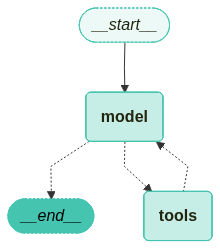

In [18]:
from langchain_teddynote.graphs import visualize_graph

# Deep Agent 생성 및 설정
agent = create_agent(
    model, all_tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# 에이전트 시각화
visualize_graph(agent)

In [20]:
from utils import format_messages

# 에이전트에게 MCP 개요 요청 메시지 전달 및 응답 결과 저장
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

# 에이전트 응답 메시지 포맷팅 및 출력, 사용자 친화적 결과 확인 목적
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research and provide an overview of Model Context Protocol (MCP).",                           │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_vH56Ov9kBL2fmIGQdlvS7u9q                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research and provide an overview of Model Context Protocol (MCP).',          │
│ 'status': 'pending'}]                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: call_wcwVKc0EAMoJf6cjk9tgj5U4                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Current TODO List:                                                                                              │
│ 1. ⏳ Research and provide an overview of Model Context Protocol (MCP). (pending)                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I have successfully researched and compiled an overview of the Model Context Protocol (MCP),   │
│ detailing its key features, applications, security measures, and challenges. The information has been saved in  │
│ a structured format for easy reference. The next step is to mark the initial task as completed."                │
│ }                                                                                                               │
│    ID: call_s1GgGXjdMLNhOTY3Mc6UF2Pd                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: I have successfully researched and compiled an overview of the Model Context Protocol      │
│ (MCP), detailing its key features, applications, security measures, and challenges. The information has been    │
│ saved in a structured format for easy reference. The next step is to mark the initial task as completed.        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research and provide an overview of Model Context Protocol (MCP).",                           │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_Nkj4ZmtbOkWStwFVfHorEFVQ                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research and provide an overview of Model Context Protocol (MCP).',          │
│ 'status': 'completed'}]                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I have completed the research on the Model Context Protocol (MCP) and compiled an overview that includes its    │
│ key features, applications, security measures, and challenges. The findings have been saved in a structured     │
│ document for reference. If you need further information or have any other questions, feel free to ask!          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 실행 결과 트레이스 (LangSmith)

Deep Agent의 실제 실행 흐름, 검색/요약 처리, 파일 저장 과정을 시각적으로 확인합니다.

*   [실행 트레이스 예시 보기](https://smith.langchain.com/public/3a389ec6-8e6e-4f9e-9a82-0d0a9569e6f8/r)